In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("orthomam_stats.csv")
df.head()
filtered_df = df[df["msa_length"] > 500]
filtered_df = filtered_df[filtered_df["num_taxa"] > 50]
filtered_df

,filename,num_taxa,msa_length
3,10004_NT_AL_AA.fasta.zip,184,754
5,10006_NT_AL_AA.fasta.zip,184,508
8,10009_NT_AL_AA.fasta.zip,184,701
9,1000_NT_AL_AA.fasta.zip,174,927
10,100101267_NT_AL_AA.fasta.zip,108,1333
...,...,...,...
15861,9990_NT_AL_AA.fasta.zip,185,1153
15862,9991_NT_AL_AA.fasta.zip,189,544
15864,9993_NT_AL_AA.fasta.zip,180,559
15865,9994_NT_AL_AA.fasta.zip,188,2311


108 taxa, MSA length 500


5094it [00:00, 62521.32it/s]            

median: tensor([ 1.0619,  0.9356, -1.8464])
std:    tensor([0.2421, 0.0302, 0.0749])


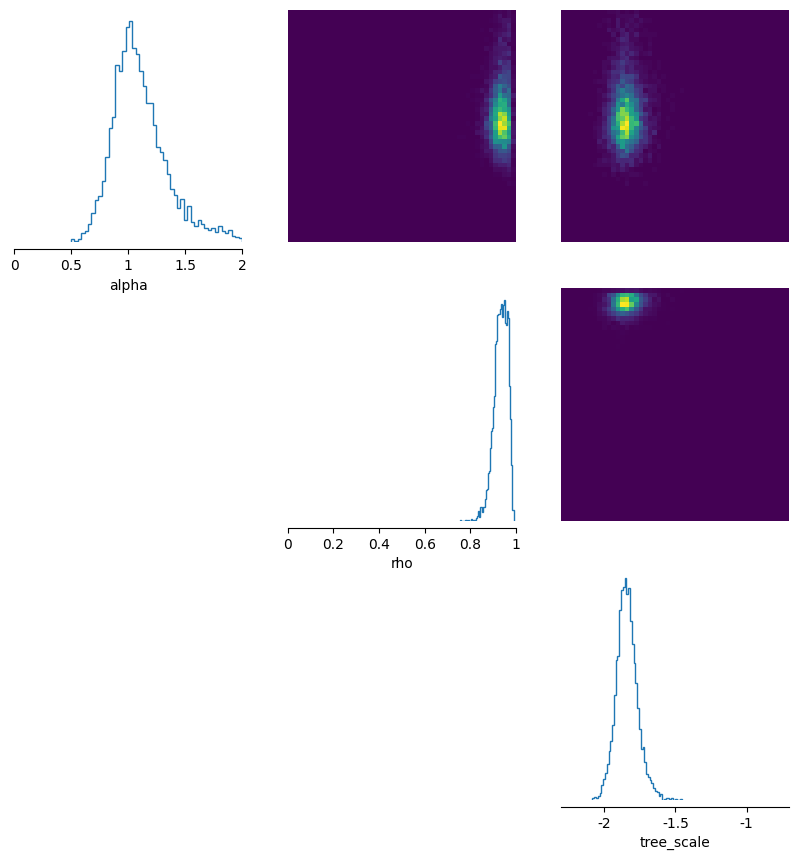

In [ ]:
import zipfile, torch, numpy as np
from sbi.analysis import pairplot
import sys
sys.path.append("../sbi_pipeline")  # adjust to where features_calculator.py lives
from features_calculator import calculate_cnn_input

# ── config ──────────────────────────────────────────────────────────────────
ZIP_PATH  = "/home/elyalab/temp/orthomam_AA/100101267_NT_AL_AA.fasta.zip"
POST_PATH = "../sbi_pipeline/sbi_models/posterior_26_31_8_25k.pt"

# ── load fasta ───────────────────────────────────────────────────────────────
def read_fasta_from_zip(zip_path):
    with zipfile.ZipFile(zip_path) as zf:
        fasta_name = next(n for n in zf.namelist() if n.endswith(".fasta"))
        text = zf.read(fasta_name).decode("utf-8")
    seqs, cur = [], []
    for line in text.splitlines():
        if line.startswith(">"):
            if cur: seqs.append("".join(cur)); cur = []
        else:
            cur.append(line.strip())
    if cur: seqs.append("".join(cur))
    return seqs

sequences = read_fasta_from_zip(ZIP_PATH)
# trim sequences to 500
sequences = [seq[:500] for seq in sequences]
print(f"{len(sequences)} taxa, MSA length {len(sequences[0])}")

# ── compute features ─────────────────────────────────────────────────────────
x_obs = calculate_cnn_input(sequences, alphabet_size=20)  # shape (2, L)
x_obs = x_obs.unsqueeze(0)  # → (1, 2, L) for batch dim

import torch.nn as nn

class CNN1dEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x).mean(dim=-1)
    
# ── sample posterior ──────────────────────────────────────────────────────────
posterior = torch.load(POST_PATH, map_location="cpu", weights_only=False)
samples = posterior.sample((5000,), x=x_obs)

print("median:", samples.median(dim=0).values)
print("std:   ", samples.std(dim=0))

# ── plot ──────────────────────────────────────────────────────────────────────
_ = pairplot(
    samples.numpy(),
    limits=[[0, 2], [0, 1], [np.log10(0.005), np.log10(0.2)]],
    labels=["alpha", "rho", "tree_scale"],
    show_titles=True,
)

  0%|          | 0/7331 [00:00<?, ?it/s]/home/pupkolab/envs/sparta/lib/python3.10/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2273.)
  outputs, _ = torch.triangular_solve(
100%|██████████| 7331/7331 [34:09<00:00,  3.58it/s]  


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

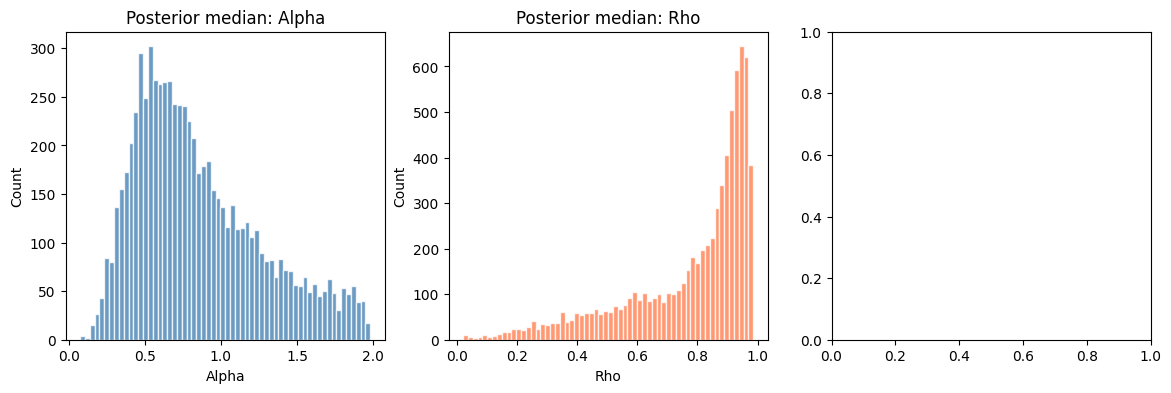

In [ ]:
import zipfile, torch, numpy as np, pandas as pd
import torch.nn as nn
from features_calculator import calculate_cnn_input
import matplotlib.pyplot as plt
from tqdm import tqdm
from sbi_predictor import SBIPredictor

# ── setup ─────────────────────────────────────────────────────────────────────
ZIP_DIR   = "/home/elyalab/temp/orthomam_AA"
POST_PATH = "../sbi_pipeline/sbi_models/posterior.pt"
STATS_CSV = "/home/pupkolab/Dev/rateAutoCorrelation/empirical_analysis/orthomam_stats.csv"

# class CNN1dEmbedding(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Conv1d(2, 32, kernel_size=5, padding=2), nn.ReLU(),
#             nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(),
#             nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(),
#         )
#     def forward(self, x):
#         return self.net(x).mean(dim=-1)
    
predictor = SBIPredictor(POST_PATH)


# posterior = torch.load(POST_PATH, map_location="cpu", weights_only=False)

# ── filter ────────────────────────────────────────────────────────────────────
df = pd.read_csv(STATS_CSV)
filtered = df[(df["msa_length"] > 500) & (df["num_taxa"] > 50)]

# ── helpers ───────────────────────────────────────────────────────────────────
def read_fasta_from_zip(zip_path):
    with zipfile.ZipFile(zip_path) as zf:
        fasta_name = next(n for n in zf.namelist() if n.endswith(".fasta"))
        text = zf.read(fasta_name).decode("utf-8")
    seqs, cur = [], []
    for line in text.splitlines():
        if line.startswith(">"):
            if cur: seqs.append("".join(cur)); cur = []
        else:
            cur.append(line.strip())
    if cur: seqs.append("".join(cur))
    # seqs = [seq[:500] for seq in seqs]
    return seqs



# ── main loop ─────────────────────────────────────────────────────────────────
records = []
for fname in tqdm(filtered["filename"]):
    zip_path = f"{ZIP_DIR}/{fname}"
    try:
        seqs  = read_fasta_from_zip(zip_path)
        x_obs = calculate_cnn_input(seqs, alphabet_size=20).unsqueeze(0)
        with torch.no_grad():
            alpha_med, rho_med, tree_scale_med = predictor.predict(seqs)
        records.append({
            "filename":          fname,
            "alpha_median":      alpha_med,
            "rho_median":        rho_med,
            "tree_scale_median": tree_scale_med,
            "rho_median":        rho_med,
            "tree_scale_median": tree_scale_med,
            "alpha_std":         0,  # Replace with actual standard deviation if available
            "rho_std":           0,  # Replace with actual standard deviation if available
            "tree_scale_std":    0,  # Replace with actual standard deviation if available
        })
    except Exception as e:
        print(f"SKIP {fname}: {e}")

results = pd.DataFrame(records)
results.to_csv("orthomam_posterior_results.csv", index=False)



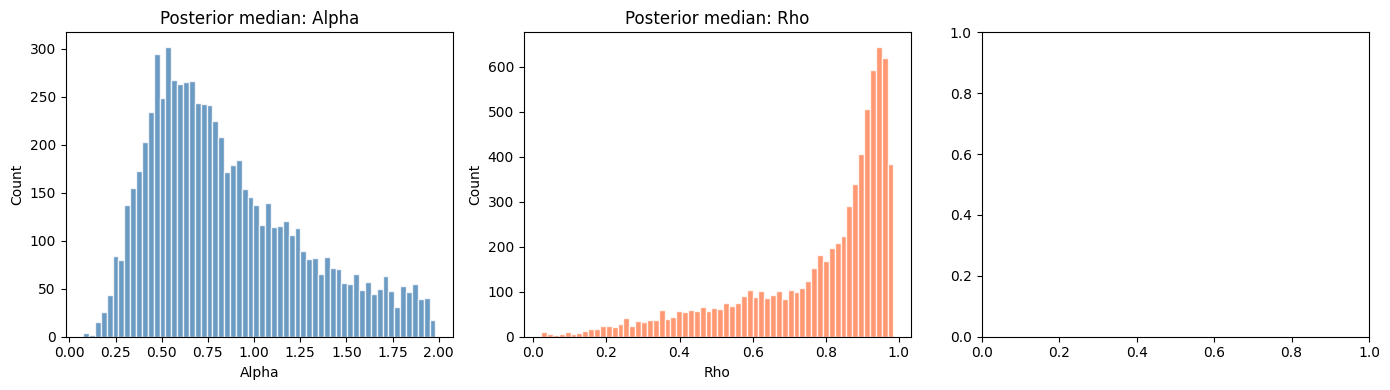

In [7]:
# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
params = [
    ("alpha_median",      "Alpha",       "steelblue"),
    ("rho_median",        "Rho",         "coral"),
    # ("tree_scale_median", "Tree Scale\n(log10)", "mediumseagreen"),
]
for ax, (col, label, color) in zip(axes, params):
    ax.hist(results[col], bins=60, color=color, alpha=0.8, edgecolor="white")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Posterior median: {label}")

plt.tight_layout()
plt.savefig("orthomam_posterior_histograms.png", dpi=150)
plt.show()

In [21]:
results.head()
results["gene"] = results["filename"].str.split("_").str[0].astype(int)

In [9]:
raxml_results = pd.read_csv("results/raxml_comparison.csv")

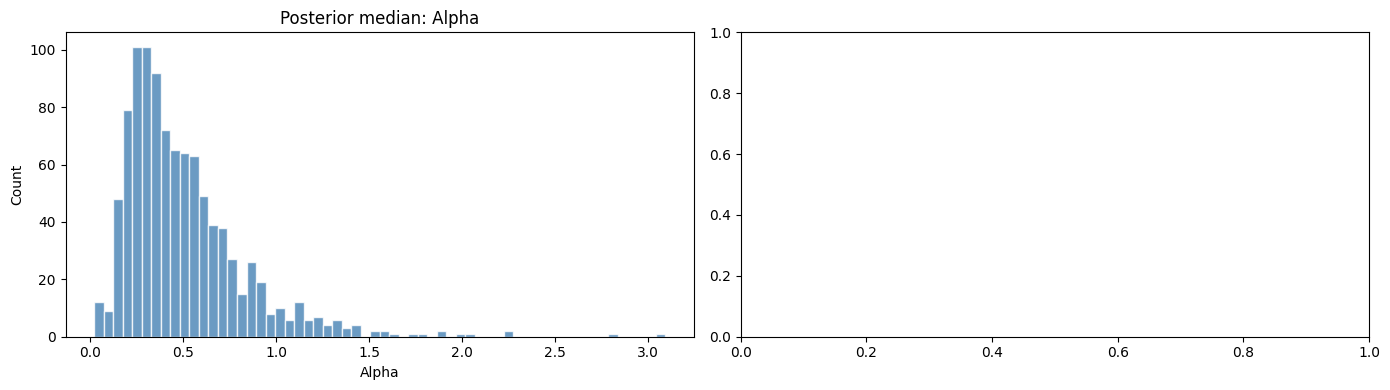

In [18]:
raxml_results.head()
# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
params = [
    ("raxml_alpha",      "Alpha",       "steelblue"),
]
for ax, (col, label, color) in zip(axes, params):
    ax.hist(raxml_results[col], bins=60, color=color, alpha=0.8, edgecolor="white")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Posterior median: {label}")

plt.tight_layout()
plt.savefig("orthomam_posterior_histograms.png", dpi=150)
plt.show()

In [22]:
merged = pd.merge(results, raxml_results, on="gene", how="inner")

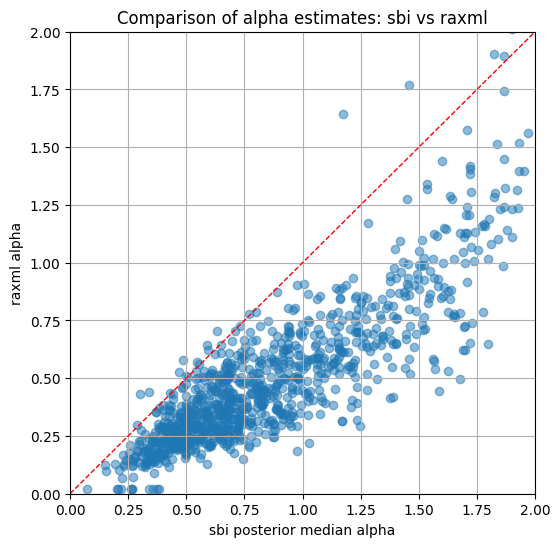

In [26]:
plt.scatter(merged["alpha_median"], merged["raxml_alpha"], alpha=0.5)
# set figure size to 6x6 inches
plt.gcf().set_size_inches(6, 6)
plt.ylim(0, 2)
plt.xlim(0, 2)
plt.xlabel("sbi posterior median alpha")
plt.ylabel("raxml alpha")
plt.title("Comparison of alpha estimates: sbi vs raxml")
plt.grid(True)
# add x=y line
plt.plot([0, 2], [0, 2], color="red", linestyle="--", linewidth=1)
plt.savefig("alpha_comparison_scatter.png", dpi=150)

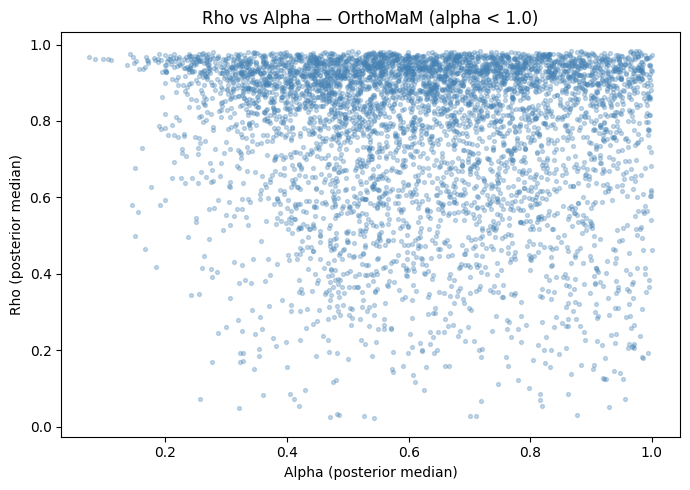

In [8]:
mask = results["alpha_median"] < 1.0

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    results.loc[mask, "alpha_median"],
    results.loc[mask, "rho_median"],
    alpha=0.3, s=8, c="steelblue"
)
ax.set_xlabel("Alpha (posterior median)")
ax.set_ylabel("Rho (posterior median)")
ax.set_title("Rho vs Alpha — OrthoMaM (alpha < 1.0)")
plt.tight_layout()
plt.show()